# Non-linear systems in 2D

### Example: 

Consider the system of nonlinear differential equations:
$$
\dot{x} = x + e^{-y}
$$

$$
\dot{y} = -y
$$

1. Use **qualitative arguments** to obtain information about the phase portrait (i.e., find equilibrium points, nullclines, and classify the stability).

2. Using a computer (via Python code), plot the **vector field**.

3. Use the **Runge-Kutta method** to compute several trajectories and plot them on the phase plane.

### 1. Use qualitative arguments to obtain information about the phase portrait (i.e., find equilibrium points, nullclines, and classify the stability).

### 2. Using a computer (via Python code), plot the direction field.

### Phase Diagram

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

In [2]:
# Slope function for the derivatives

def ode_system(t, s):
    """
    Inputs: t -> time
            s -> (x,y)
    Return: [dxt, dyt]
    """
    # Get the state
    x, y = s
    
    # Slopes
    dxt = x + np.exp(-y)
    dyt = -y

    return [dxt, dyt]

In [3]:
# Set limits for the axes 
xl, xr = -5., +5.
yl, yr = -5., +5.

# Resolution
nx = ny = 20

# Axes
x_1d = np.linspace(xl, xr, nx)
y_1d = np.linspace(xl, xr, ny)

# Create meshgrid
x_2d, y_2d = np.meshgrid(x_1d, y_1d)

# Add the vector components for the velocities (derivatives)
vx_2d = x_2d + np.exp(-y_2d)
vy_2d = -y_2d

# Velocity Magnitude 
v_mag = np.sqrt(vx_2d**2 + vy_2d**2)

# Normalise
vx_2d = vx_2d / v_mag 
vy_2d = vy_2d / v_mag 

# Fixed point
x0, y0 = (-1., 0.)


# Nullclines
y_null = 0.

x_null = -np.exp(-y_1d)

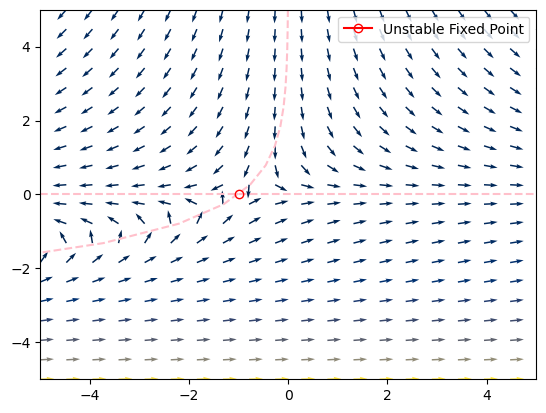

In [9]:
# Phase diagram
plt.figure()

plt.axhline(y_null, color = "pink", linestyle = "--")

plt.plot(x_null, y_1d, color = "pink", linestyle = "--")

plt.plot(x0, y0, marker = "o", color = "red", fillstyle = "none", label = "Unstable Fixed Point")
plt.quiver(x_2d, y_2d, vx_2d, vy_2d, v_mag, cmap = "cividis")

plt.xlim(xl, xr)
plt.ylim(yl, yr)

plt.legend()
plt.show()


### 3. Use the Runge-Kutta method to compute several trajectories and plot them on the phase plane.

In [15]:
# Integrator -> SciPy

def compute_traj(ics_input):
    """
    """
    # Get ICs
    x0, y0 = ics_input

    # Forward in time integrator
    sln = sc.integrate.solve_ivp(ode_system, t_limits, [x0, y0], t_eval = t_axis, method = "RK45")
    
    return sln.y[0], sln.y[1]

In [12]:
# Time discretisation
t_limits = [0., 5.]

# Number of time steps
n_t = 100

# Time axis
t_axis = np.linspace(t_limits[0], t_limits[1], n_t)


In [17]:
# Initial conditions
ics = [[-3., 2.], [0.,-3.]]

# Integrate for ics
sol_x, sol_y = compute_traj(ics[0])

print(sol_x.shape, sol_y.shape)

(100,) (100,)


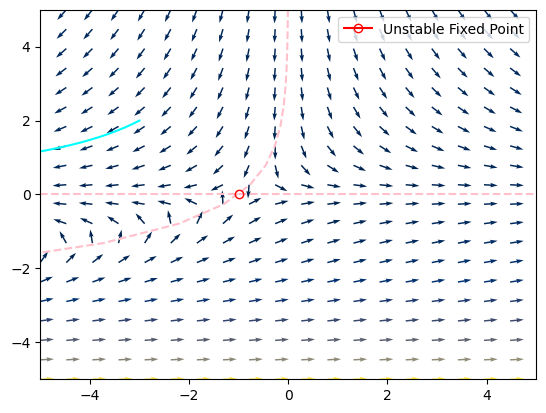

In [18]:
# Phase diagram
plt.figure()

plt.axhline(y_null, color = "pink", linestyle = "--")

plt.plot(x_null, y_1d, color = "pink", linestyle = "--")

plt.plot(x0, y0, marker = "o", color = "red", fillstyle = "none", label = "Unstable Fixed Point")
plt.quiver(x_2d, y_2d, vx_2d, vy_2d, v_mag, cmap = "cividis")

# Add the trajectories
plt.plot(sol_x, sol_y, color = "cyan", linestyle = "-")

plt.xlim(xl, xr)
plt.ylim(yl, yr)

plt.legend()
plt.show()
